In [1]:
import sys,os

from qiskit import BasicAer,execute
backend = BasicAer.get_backend("dm_simulator")
options= {
    "thermal_factor": 1,
    "decoherence_factor": 0.9,
    "depolarization_factor": 1,
    "bell_depolarization_factor": 1,
    "decay_factor": 0.9,
    "rotation_error": {'rx':[1., 0.], 'ry':[1., 0.], 'rz': [1., 0.]},
    "tsp_model_error": [1., 0.],
    "plot": False
}

# Get the absolute path of the project's root directory
cd = os.path.abspath(os.path.join(os.path.dirname("qsim-superstaq"), '..'))

# Add the utils and models directories to sys.path
sys.path.insert(0, os.path.join(cd, 'supermarq-benchmarks/supermarq/benchmarks'))
sys.path.insert(0, os.path.join(cd, 'supermarq-benchmarks/supermarq'))
sys.path.insert(0, os.path.join(cd, 'supermarq-benchmarks'))

In [2]:
from plotting import *
from converters import *
from benchmarks import GHZ, BitCode, HamiltonianSimulation, MerminBell, PhaseCode, QAOAFermionicSwapProxy, QAOAVanillaProxy, VQEProxy

In [3]:
qubits = 5
ghz_qubits = 6
mb_qubits = 7
ham_qubits = 3
qaoaf_qubits = 5
qaoav_qubits = 4
vqep_qubits = 8
shots=1000

In [4]:
import time
def run(benchmark_class,qubits,shots,name):
    
    benchmark_obj = benchmark_class(qubits)
    
    # Calculate Creation time 
    t_c = time.time()
    qc= benchmark_obj.qiskit_circuit()
    creation_time = time.time()-t_c  #in sec
    print(qc)

    # Calculate Execution time 
    t_e = time.time()
    job = execute(qc, backend, shots=shots, **options)
    result = job.result()
    execution_time = time.time() - t_e #in sec

    # Calculate quantum processing time 
    quantum_time = (result.time_taken) #in sec
    
    counts = result.results[0].data.partial_probability
    for key in counts.keys():
        counts[key] = int(counts[key] * shots)
    
    print("counts : ",counts)
    score = benchmark_obj.score(counts)
    print("Score : ",score)

    print(f"Creation, execution and Quantum Times = {creation_time},{execution_time} & {quantum_time} seconds")

    benchmark_name = f"{name}-{qubits}"
    plot_results([score],[benchmark_name])

    features = [
    compute_communication_with_qiskit(qc),
    compute_depth_with_qiskit(qc),
    compute_entanglement_with_qiskit(qc),
    compute_liveness_with_qiskit(qc),
    compute_measurement_with_qiskit(qc),
    compute_parallelism_with_qiskit(qc),
    ]
    print("Features :",features)

    plot_benchmark(title=f"A single {name} benchmark",labels=[benchmark_name],features=[features],
                   spoke_labels=["PC", "CD", "Ent", "Liv", "Mea", "Par"] )
    

# GHZ :

     ┌───┐          ┌─┐                              
q_0: ┤ H ├──■───────┤M├──────────────────────────────
     └───┘┌─┴─┐     └╥┘     ┌─┐                      
q_1: ─────┤ X ├──■───╫──────┤M├──────────────────────
          └───┘┌─┴─┐ ║      └╥┘     ┌─┐              
q_2: ──────────┤ X ├─╫───■───╫──────┤M├──────────────
               └───┘ ║ ┌─┴─┐ ║      └╥┘     ┌─┐      
q_3: ────────────────╫─┤ X ├─╫───■───╫──────┤M├──────
                     ║ └───┘ ║ ┌─┴─┐ ║      └╥┘┌─┐   
q_4: ────────────────╫───────╫─┤ X ├─╫───■───╫─┤M├───
                     ║       ║ └───┘ ║ ┌─┴─┐ ║ └╥┘┌─┐
q_5: ────────────────╫───────╫───────╫─┤ X ├─╫──╫─┤M├
                     ║       ║       ║ └───┘ ║  ║ └╥┘
c: 6/════════════════╩═══════╩═══════╩═══════╩══╩══╩═
                     0       1       2       3  4  5 
counts :  {'000000': 575, '000001': 0, '000010': 0, '000011': 1, '000100': 1, '000101': 0, '000110': 0, '000111': 7, '001000': 4, '001001': 0, '001010': 0, '001011': 4, '001100': 2, '001101'

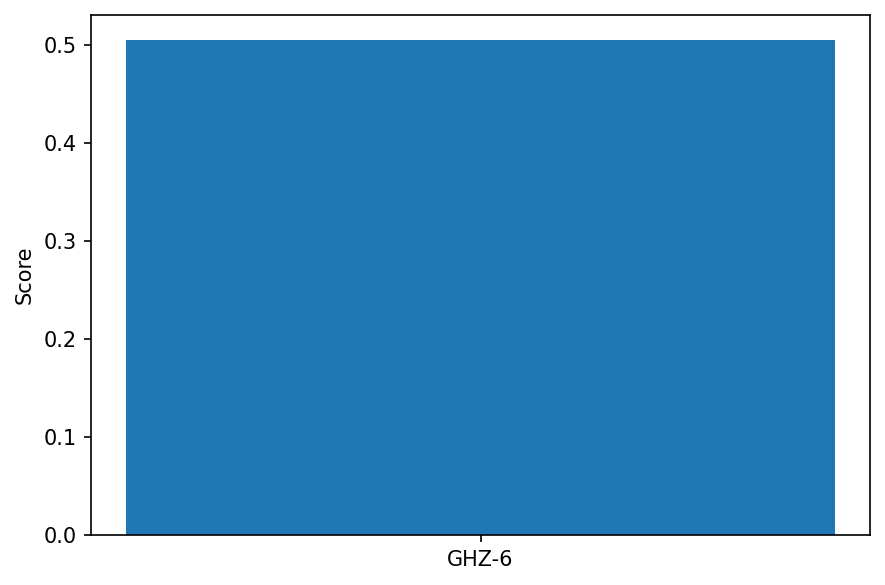

Features : [0.3333333333333333, 1.0, 0.8333333333333334, 0.40476190476190477, 0.0, 0.0]


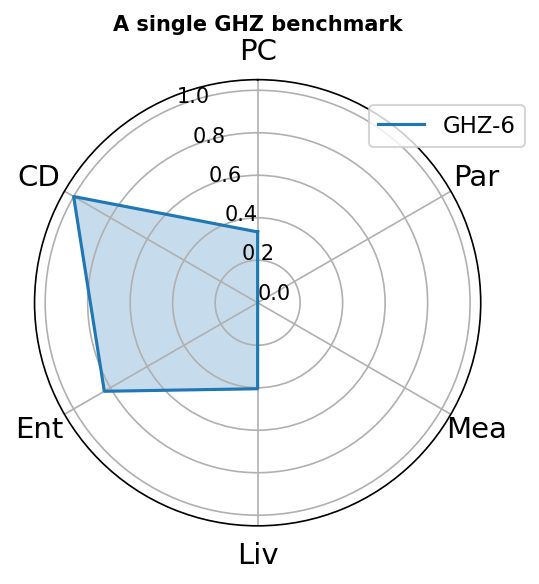

In [5]:
run(GHZ,qubits=ghz_qubits,shots=shots,name="GHZ")

# Bitcode

In [6]:
# # '''
# #     Args:
# #         num_data: The number of data qubits.
# #         num_rounds: The number of measurement rounds.
# #         bit_state: A list denoting the state to initialize each data qubit to.

# #     Returns:
# #         A `cirq.Circuit` for the bit-flip error correcting code.
# # '''

# # num_data_qubits = 3
# # num_rounds = 1
# # bit_state = [1, 1, 1]

# qubits = 3

# bc = BitCode(3,1,[1,1,1])
# bc_ckt = bc.circuit()
# #only Cirq's implementation for ckt creation
# bc_ckt = cirq_to_qiskit(bc_ckt)
# print(bc_ckt)

# job = execute(bc_ckt, backend, shots=shots, **options)
# counts = job.result().results[0]#.data.partial_probability
# print(counts)
# for key in counts.keys():
#     counts[key] = int(counts[key] * shots)
    
# print("counts : ",counts)
# score = bc.score(counts)
# print("Score : ",score)

# name = "Bitcode"

# benchmark_name = f"{name}-{qubits}"
# plot_results([score],[benchmark_name])

# features = [
# compute_communication_with_qiskit(bc_ckt),
# compute_depth_with_qiskit(bc_ckt),
# compute_entanglement_with_qiskit(bc_ckt),
# compute_liveness_with_qiskit(bc_ckt),
# compute_measurement_with_qiskit(bc_ckt),
# compute_parallelism_with_qiskit(bc_ckt),
# ]
# print("Features :",features)

# plot_benchmark(title=f"A single {name} benchmark",labels=[benchmark_name],features=[features],
#                    spoke_labels=["PC", "CD", "Ent", "Liv", "Mea", "Par"] )

# Hamiltonian_Simulation:

     ┌───┐┌───────────┐┌───┐                           ┌─┐                    »
q_0: ┤ H ├┤ Rz(-3π/4) ├┤ H ├──■────────────────■───────┤M├────────────────────»
     ├───┤├───────────┤├───┤┌─┴─┐┌──────────┐┌─┴─┐     └╥┘                 ┌─┐»
q_1: ┤ H ├┤ Rz(-3π/4) ├┤ H ├┤ X ├┤ Rz(-π/2) ├┤ X ├──■───╫───────────────■──┤M├»
     ├───┤├───────────┤├───┤└───┘└──────────┘└───┘┌─┴─┐ ║ ┌──────────┐┌─┴─┐└╥┘»
q_2: ┤ H ├┤ Rz(-3π/4) ├┤ H ├──────────────────────┤ X ├─╫─┤ Rz(-π/2) ├┤ X ├─╫─»
     └───┘└───────────┘└───┘                      └───┘ ║ └──────────┘└───┘ ║ »
c: 3/═══════════════════════════════════════════════════╩═══════════════════╩═»
                                                        0                   1 »
«        
«q_0: ───
«        
«q_1: ───
«     ┌─┐
«q_2: ┤M├
«     └╥┘
«c: 3/═╩═
«      2 
counts :  {'000': 217, '001': 148, '010': 95, '011': 131, '100': 113, '101': 77, '110': 91, '111': 125}
Score :  0.5907796084037169
Creation, execution and Quantum Times = 0.0003182888031005

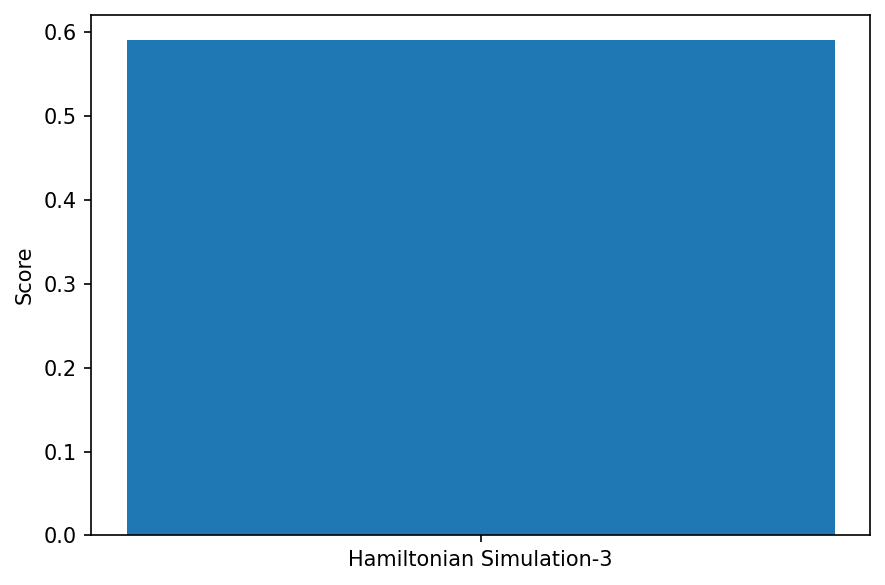

Features : [0.6666666666666666, 1.0, 0.26666666666666666, 0.7333333333333333, 0.0, 0.33333333333333337]


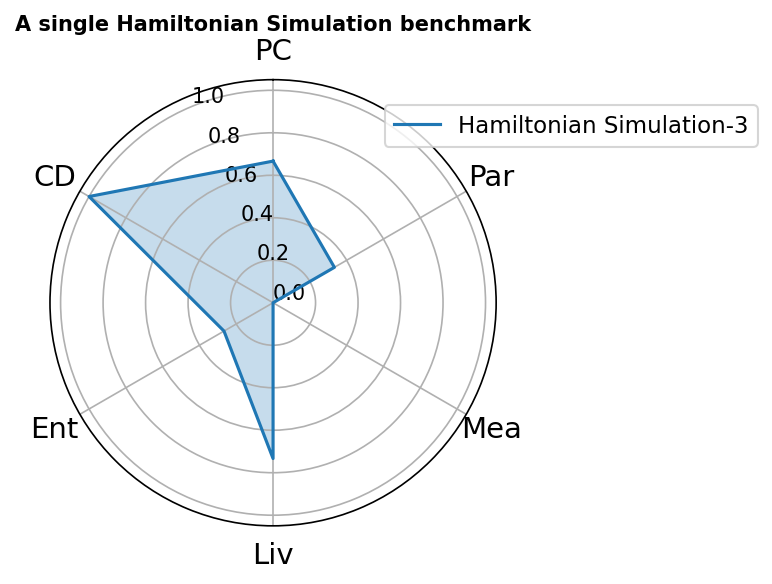

In [7]:
run(HamiltonianSimulation,qubits=ham_qubits,shots=shots,name="Hamiltonian Simulation")

# MerminBell

      ┌──────────┐                                                          »
 q_0: ┤ Rx(-π/2) ├──■─────────────────────────────────────■─────────────────»
      └──────────┘┌─┴─┐     ┌───┐                         │                 »
 q_1: ────────────┤ X ├──■──┤ H ├─────────────────────X───┼────■────────────»
                  └───┘┌─┴─┐└───┘┌───┐                │   │    │            »
 q_2: ─────────────────┤ X ├──■──┤ H ├────────────X───┼───┼────┼────■───────»
                       └───┘┌─┴─┐└───┘┌───┐       │   │   │    │    │       »
 q_3: ──────────────────────┤ X ├──■──┤ H ├───────┼───┼───┼────┼────┼────■──»
                            └───┘┌─┴─┐└───┘┌───┐  │   │   │    │    │    │  »
 q_4: ───────────────────────────┤ X ├──■──┤ H ├──X───┼───┼────┼────┼────┼──»
                                 └───┘┌─┴─┐└───┘┌───┐ │   │    │    │    │  »
 q_5: ────────────────────────────────┤ X ├──■──┤ H ├─X───┼────┼────┼────┼──»
                                      └───┘┌─┴─┐├───┤   ┌─┴─┐┌─┴

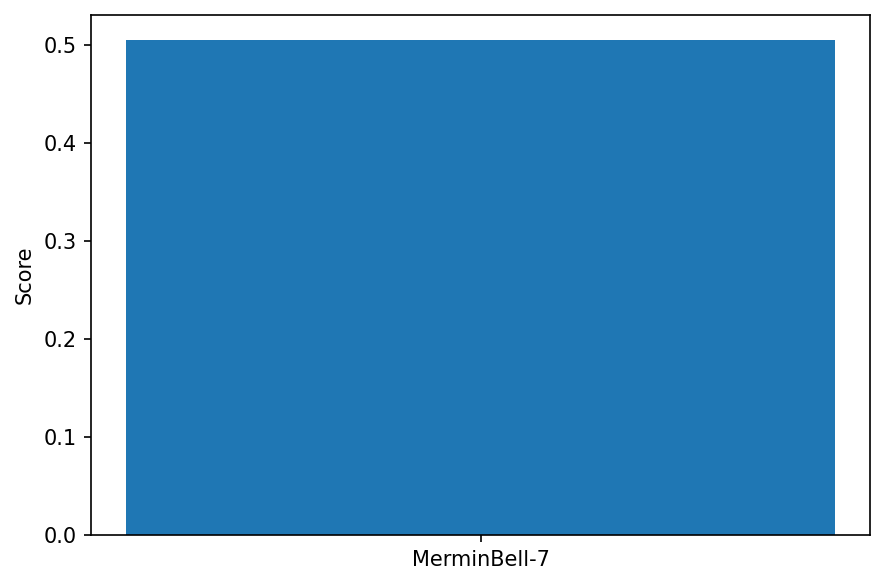

Features : [1.0, 0.7714285714285715, 0.625, 0.42424242424242425, 0.0, 0.125]


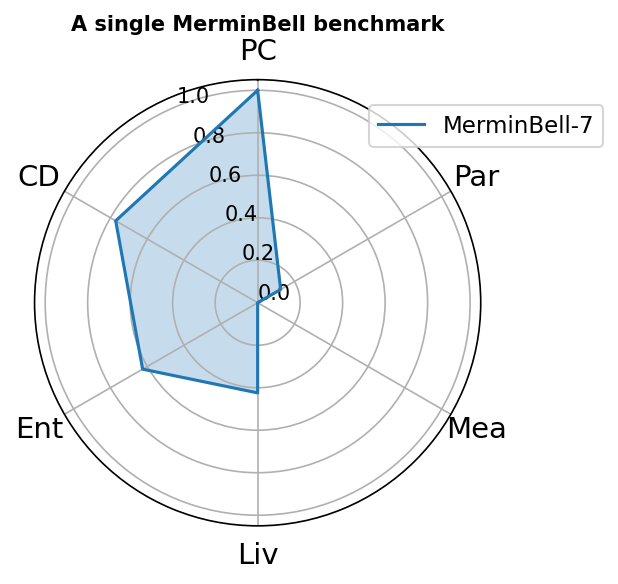

In [8]:
run(MerminBell,qubits=mb_qubits,shots=shots,name="MerminBell")

# PhaseCode :

In [9]:
# # Only cirq circuit implementation is given


# # num_data_qubits = 3
# # num_rounds = 1
# # phase_state = [1, 1, 1]

# qubits = 3

# pc = PhaseCode(3, 1, [1, 1, 1])
# pc_ckt = bc.circuit()
# #only Cirq's implementation for ckt creation
# pc_ckt = cirq_to_qiskit(pc_ckt)
# print(pc_ckt)

# job = execute(pc_ckt, backend, shots=shots, **options)
# counts = job.result().results[0].data.partial_probability
# for key in counts.keys():
#     counts[key] = int(counts[key] * shots)
    
# print("counts : ",counts)
# score = pc.score(counts)
# print("Score : ",score)

# name = "Bitcode"

# benchmark_name = f"{name}-{qubits}"
# plot_results([score],[benchmark_name])

# features = [
# compute_communication_with_qiskit(pc_ckt),
# compute_depth_with_qiskit(pc_ckt),
# compute_entanglement_with_qiskit(pc_ckt),
# compute_liveness_with_qiskit(pc_ckt),
# compute_measurement_with_qiskit(pc_ckt),
# compute_parallelism_with_qiskit(pc_ckt),
# ]
# print("Features :",features)

# plot_benchmark(title=f"A single {name} benchmark",labels=[benchmark_name],features=[features],
#                    spoke_labels=["PC", "CD", "Ent", "Liv", "Mea", "Par"] )

#  QAOAFermionicSwapProxy:

      ┌───┐                    ┌───┐                                        »
 q_0: ┤ H ├──■─────────────────┤ X ├──■──────────────────────────────────■──»
      ├───┤┌─┴─┐┌─────────────┐└─┬─┘┌─┴─┐                    ┌───┐     ┌─┴─┐»
 q_1: ┤ H ├┤ X ├┤ Rz(-6.8263) ├──■──┤ X ├──■─────────────────┤ X ├──■──┤ X ├»
      ├───┤└───┘└─────────────┘┌───┐└───┘┌─┴─┐┌─────────────┐└─┬─┘┌─┴─┐└───┘»
 q_2: ┤ H ├──■─────────────────┤ X ├──■──┤ X ├┤ Rz(-6.8263) ├──■──┤ X ├──■──»
      ├───┤┌─┴─┐ ┌────────────┐└─┬─┘┌─┴─┐└───┘└─────────────┘┌───┐└───┘┌─┴─┐»
 q_3: ┤ H ├┤ X ├─┤ Rz(6.8263) ├──■──┤ X ├──■─────────────────┤ X ├──■──┤ X ├»
      ├───┤└───┘ └────────────┘     └───┘┌─┴─┐┌─────────────┐└─┬─┘┌─┴─┐└───┘»
 q_4: ┤ H ├──────────────────────────────┤ X ├┤ Rz(-6.8263) ├──■──┤ X ├─────»
      └───┘                              └───┘└─────────────┘     └───┘     »
m0: 5/══════════════════════════════════════════════════════════════════════»
                                                                

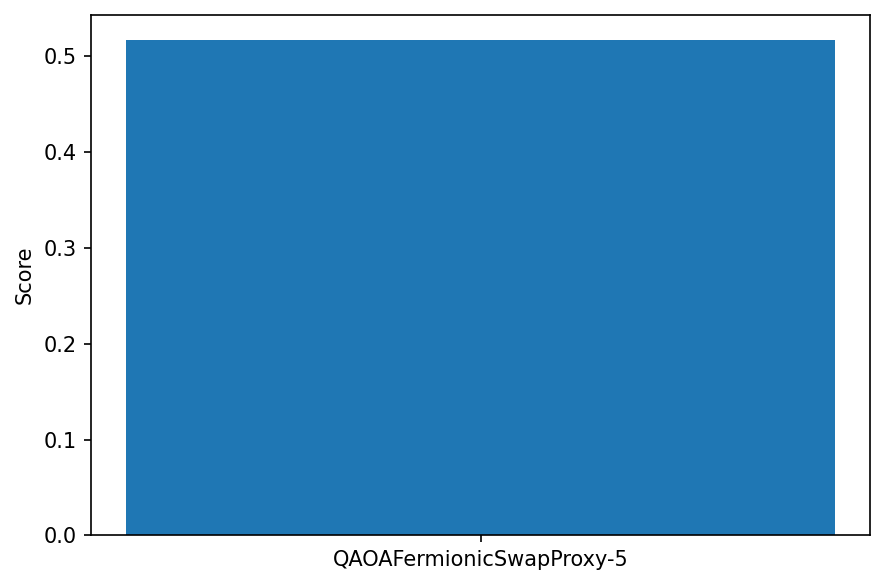

Features : [0.4, 0.5, 0.6, 0.7391304347826086, 0.0, 0.31818181818181823]


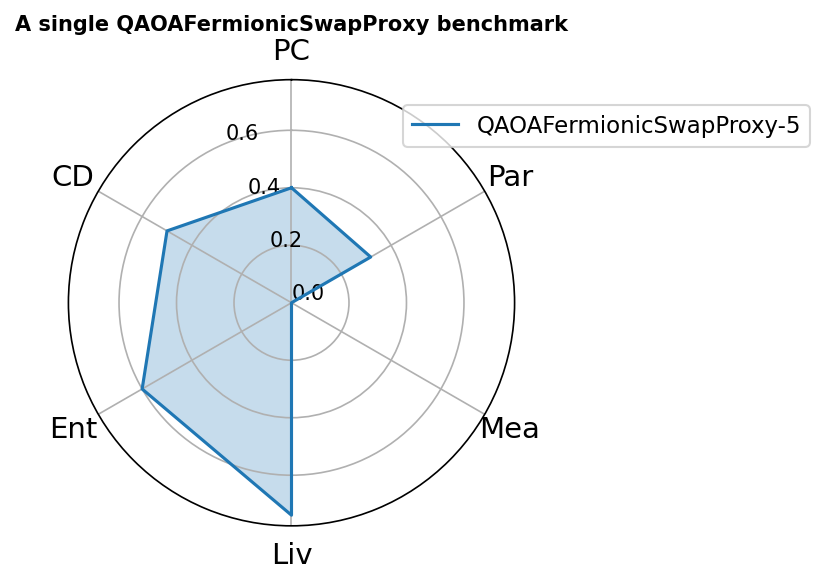

In [10]:
run(QAOAFermionicSwapProxy,qubits=qaoaf_qubits,shots=shots,name="QAOAFermionicSwapProxy")

# QAOAVanillaProxy :

      ┌───┐                                                                   »
 q_0: ┤ H ├──■──────────────────■─────────────────────────────────────────────»
      ├───┤  │                  │                                             »
 q_1: ┤ H ├──┼──────────────────┼────────────────────────────■────────────────»
      ├───┤┌─┴─┐┌────────────┐┌─┴─┐                          │                »
 q_2: ┤ H ├┤ X ├┤ Rz(12.075) ├┤ X ├──■──────────────────■────┼────────────────»
      ├───┤└───┘└────────────┘└───┘┌─┴─┐┌────────────┐┌─┴─┐┌─┴─┐┌────────────┐»
 q_3: ┤ H ├────────────────────────┤ X ├┤ Rz(12.075) ├┤ X ├┤ X ├┤ Rz(12.075) ├»
      └───┘                        └───┘└────────────┘└───┘└───┘└────────────┘»
m0: 4/════════════════════════════════════════════════════════════════════════»
                                                                              »
«                                                                              »
« q_0: ───────■──────────────────■────■

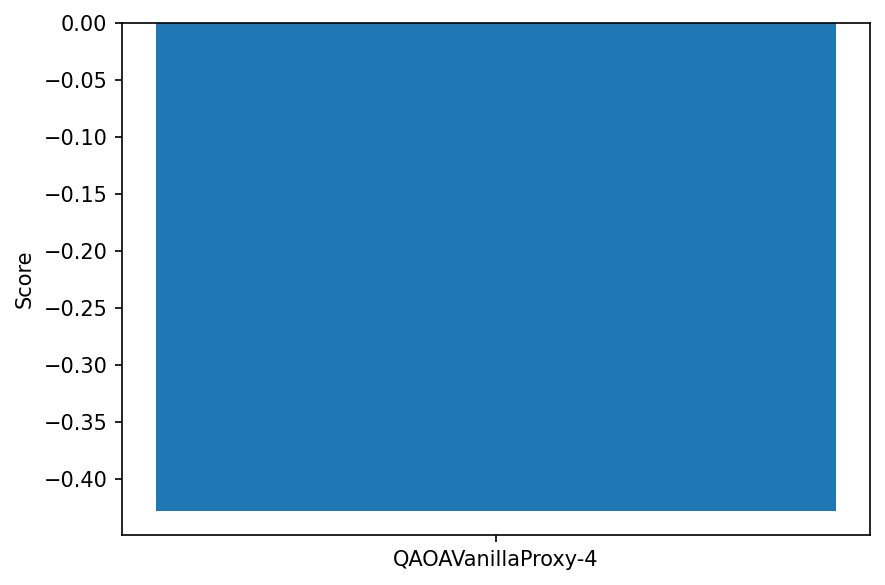

Features : [1.0, 0.8333333333333334, 0.46153846153846156, 0.5833333333333334, 0.0, 0.17647058823529407]


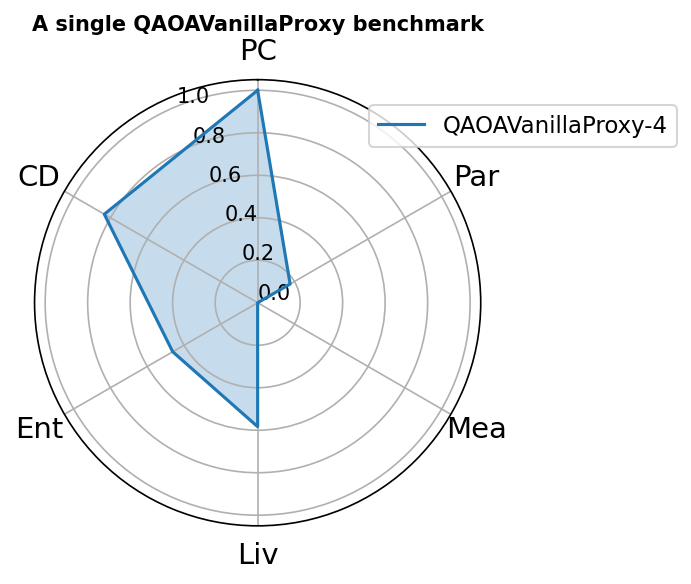

In [11]:
run(QAOAVanillaProxy,qubits=qaoav_qubits,shots=shots,name="QAOAVanillaProxy")

# VQEProxy:

 Creation time for 2 circuits = 8.922058582305908 sec
0: ───Ry(0.001π)───Rz(0.223π)───@───Ry(0.831π)───Rz(2π)─────────────────────────────────────────────────────────────M───
                                │                                                                                   │
1: ───Ry(1.0π)─────Rz(1.3π)─────X───@────────────Ry(-0.168π)───Rz(2π)───────────────────────────────────────────────M───
                                    │                                                                               │
2: ───Ry(1.03π)────Rz(1.99π)────────X────────────@─────────────Ry(-0.82π)───Rz(-π)──────────────────────────────────M───
                                                 │                                                                  │
3: ───Ry(-1.08π)───Rz(-1.91π)────────────────────X─────────────@────────────Ry(-0.246π)───Rz(-1.97π)────────────────M───
                                                               │                                            

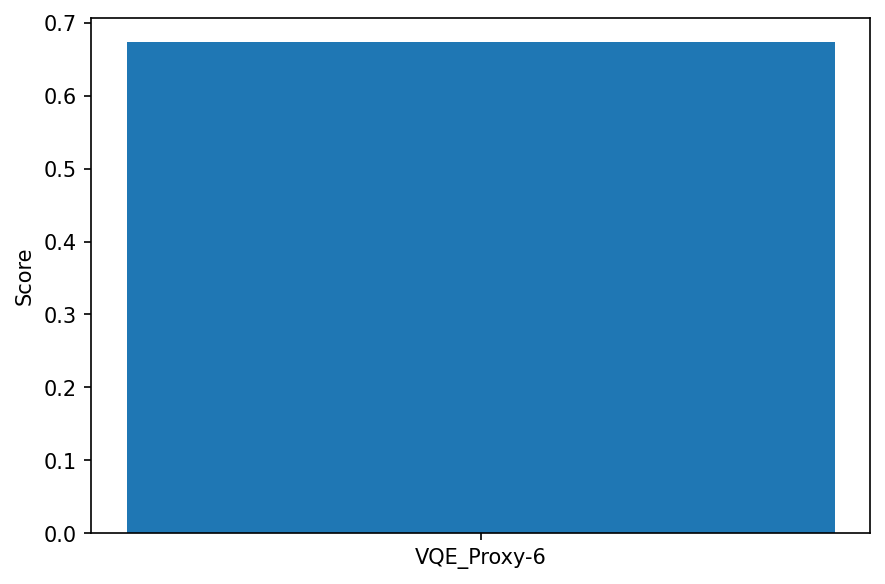

Features for ckt circuit-237: [0.3333333333333333, 1.0, 0.1724137931034483, 0.6666666666666666, 0.0, 0.4444444444444445]


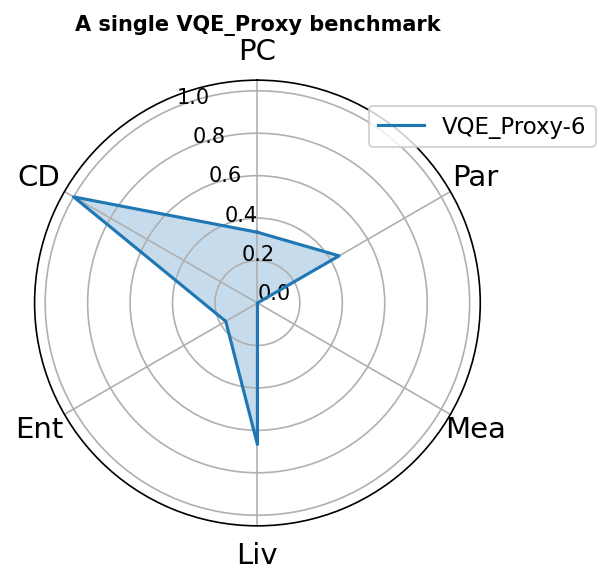

Features for ckt circuit-239: [0.3333333333333333, 1.0, 0.14285714285714285, 0.696969696969697, 0.0, 0.5]


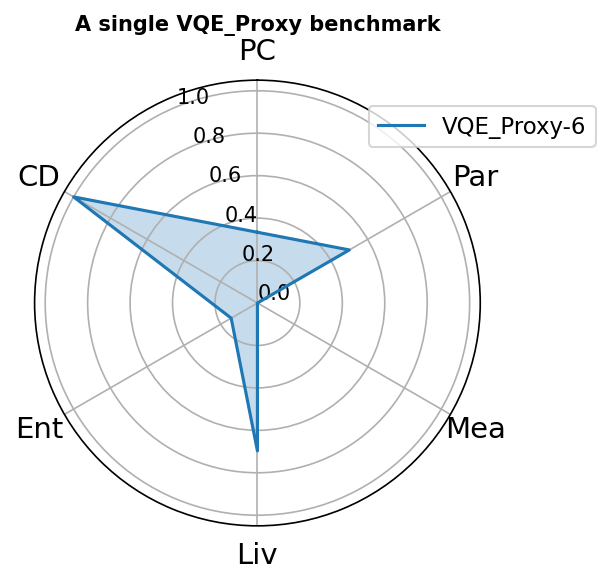

In [12]:
import simulation,time

final_counts = []
ckt_list = []

# Calculate Creation time 
t_c = time.time()
#vqe = VQEProxy(3, 1) #3 Qubits, 1 Layer
vqe = VQEProxy(6, 1)
shots = 1000
ckts =  vqe.circuit()
creation_time = time.time()-t_c

for i in ckts:
    ckt_list.append(cirq_to_qiskit(i))

print(f" Creation time for {len(ckt_list)} circuits = {creation_time} sec")

for i in ckts:
    print(i)


for i in ckt_list:
    # Calculate Execution time 
    t_e = time.time()
    job = execute(i, backend, shots=shots, **options)
    result = job.result()
    execution_time = time.time() - t_e #in sec

    # Calculate quantum processing time 
    quantum_time = (result.time_taken) #in sec

    print(f" For circuit i={i}, execution time = {execution_time} sec and quantum time = {quantum_time} sec")
    
    counts = result.results[0].data.partial_probability
    for key in counts.keys():
        counts[key] = int(counts[key] * shots)

    final_counts.append(counts)

print("Final Counts:",final_counts)
print("########################################################")
score_vqe = vqe.score(final_counts)
print(score_vqe)

name = "VQE_Proxy"
qubits = vqe.num_qubits

benchmark_name = f"{name}-{qubits}"
plot_results([score_vqe],[benchmark_name])

for i in ckt_list:
    features = [
    compute_communication_with_qiskit(i),
    compute_depth_with_qiskit(i),
    compute_entanglement_with_qiskit(i),
    compute_liveness_with_qiskit(i),
    compute_measurement_with_qiskit(i),
    compute_parallelism_with_qiskit(i),
    ]
    print(f"Features for ckt {i.name}: {features}")
    
    plot_benchmark(title=f"A single {name} benchmark",labels=[benchmark_name],features=[features],
                       spoke_labels=["PC", "CD", "Ent", "Liv", "Mea", "Par"] )
    

# correlation Plots :

In [20]:
from benchmarks import GHZ,HamiltonianSimulation
benchmark_features = {}
benchmarks_list = [
    (GHZ(5), "ghz6"),
    (HamiltonianSimulation(5), "hsim3"),
    (QAOAFermionicSwapProxy(5),"QAOAF5"),
    (QAOAVanillaProxy(5),"QAOAV4"),
    (MerminBell(5),"MB7")
]
for benchmark, label in benchmarks_list:
    benchmark_features[label] = [
        compute_communication_with_qiskit(benchmark.qiskit_circuit()),
        compute_depth_with_qiskit(benchmark.qiskit_circuit()),
        compute_entanglement_with_qiskit(benchmark.qiskit_circuit()),
        compute_liveness_with_qiskit(benchmark.qiskit_circuit()),
        compute_measurement_with_qiskit(benchmark.qiskit_circuit()),
        compute_parallelism_with_qiskit(benchmark.qiskit_circuit()),
    ]
print(benchmark_features)

{'ghz6': [0.4, 1.0, 0.8, 0.4666666666666667, 0.0, 0], 'hsim3': [0.4, 1.0, 0.2962962962962963, 0.5, 0.0, 0.171875], 'QAOAF5': [0.4, 0.5, 0.6, 0.7391304347826086, 0.0, 0.2934782608695652], 'QAOAV4': [1.0, 0.8, 0.5, 0.48148148148148145, 0.0, 0.12037037037037035], 'MB7': [1.0, 0.8947368421052632, 0.5588235294117647, 0.5043478260869565, 0.0, 0.11956521739130432]}


In [21]:
jobs = []
for benchmark, label in benchmarks_list:
    job = execute(benchmark.qiskit_circuit(), backend, shots=shots, **options)
    jobs.append((label, job, benchmark))

device_scores = {}

for label, job, benchmark in jobs:
    if job.status() == qiskit.providers.jobstatus.JobStatus.DONE:
        counts = job.result().results[0].data.partial_probability
        for key in counts.keys():
            counts[key] = int(counts[key] * shots)
        print(counts)
        score = benchmark.score(counts)
        print(score)
        device_scores[label] = score
    else:
        print(label, "not done!")

{'00000': 569, '00001': 0, '00010': 0, '00011': 4, '00100': 3, '00101': 2, '00110': 2, '00111': 20, '01000': 12, '01001': 1, '01010': 1, '01011': 12, '01100': 8, '01101': 5, '01110': 5, '01111': 54, '10000': 38, '10001': 0, '10010': 0, '10011': 9, '10100': 5, '10101': 4, '10110': 4, '10111': 38, '11000': 22, '11001': 2, '11010': 2, '11011': 24, '11100': 15, '11101': 11, '11110': 11, '11111': 102}
0.5851886008769293
{'00000': 261, '00001': 86, '00010': 70, '00011': 44, '00100': 70, '00101': 25, '00110': 30, '00111': 19, '01000': 66, '01001': 22, '01010': 19, '01011': 12, '01100': 25, '01101': 9, '01110': 11, '01111': 7, '10000': 65, '10001': 21, '10010': 17, '10011': 11, '10100': 18, '10101': 6, '10110': 7, '10111': 5, '11000': 23, '11001': 7, '11010': 6, '11011': 4, '11100': 9, '11101': 3, '11110': 3, '11111': 2}
0.3975147681045894
{'00000': 7, '00001': 5, '00010': 13, '00011': 9, '00100': 13, '00101': 10, '00110': 28, '00111': 21, '01000': 13, '01001': 9, '01010': 25, '01011': 18, '01

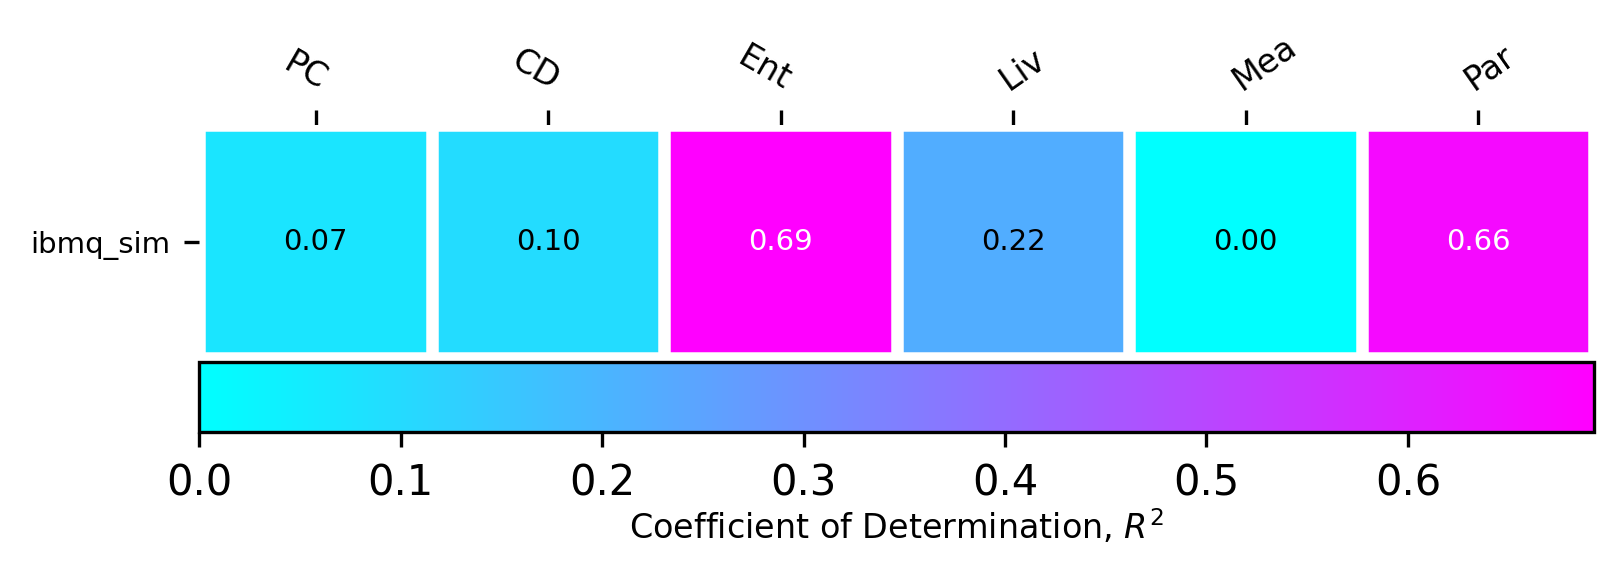

In [22]:
plot_correlations(
    benchmark_features,
    device_scores,
    ["PC", "CD", "Ent", "Liv", "Mea", "Par"],
    device_name="ibmq_sim",
)